# NHL Goal Probability as a Function of Shot Distance and Shot Angle
## Goal

The goal with this project is build upon a prior project that tracked NHL goal conversion as a function of distance
for the 2021-2022 NHL Season(see https://github.com/stefnguessan68/sports-data-projects/blob/main/NHLShots21_by_Distance.ipynb). **I will now track NHL goal conversion as a function of both distance and shot angle**.

**There is still the possibility of empty-net goals skewing the data as distance increases towards 90+, but by adding shot angle to the mix, I will be able to find the exact distance range through which the exponential decay found in shot probability is overturned**.


The dataset is from Kaggle, and tracked over 160,000 shots from the 2021-2022 NHL Season. The link to the data is provided below:
https://www.kaggle.com/datasets/mexwell/national-hockey-league-shots?resource=download 

In [92]:
import pandas as pd

df = pd.read_csv("nhl-shots-2021.csv")
df.head()

,game_id,description,shot_outcome,period,period_seconds_remaining,game_seconds_remaining,home_score,away_score,home_name,away_name,...,empty_net,event_player_1_name,event_player_1_type,event_player_2_name,event_player_2_type,strength_code,x_fixed,y_fixed,shot_distance,shot_angle
0,2021020001,Steven Stamkos Wrist Shot saved by Tristan Jarry,SHOT,1,1137,3537,0,0,Tampa Bay Lightning,Pittsburgh Penguins,...,NaN,Steven.Stamkos,Shooter,Tristan.Jarry,Goalie,EV,61.0,-32.0,42.5,48.8
1,2021020001,Zach Bogosian shot blocked shot by Brock McGinn,BLOCKED_SHOT,1,1115,3515,0,0,Tampa Bay Lightning,Pittsburgh Penguins,...,NaN,Zach.Bogosian,Shooter,Brock.McGinn,Blocker,EV,60.0,-17.0,NaN,NaN
2,2021020001,Brock McGinn Wrist Shot saved by Andrei Vasile...,SHOT,1,1096,3496,0,0,Tampa Bay Lightning,Pittsburgh Penguins,...,NaN,Brock.McGinn,Shooter,Andrei.Vasilevskiy,Goalie,EV,-65.0,19.0,30.6,38.4
3,2021020001,Jan Rutta Wrist Shot saved by Tristan Jarry,SHOT,1,1079,3479,0,0,Tampa Bay Lightning,Pittsburgh Penguins,...,NaN,Jan.Rutta,Shooter,Tristan.Jarry,Goalie,EV,-8.0,-27.0,100.7,15.6
4,2021020001,Danton Heinen Wrist Shot saved by Andrei Vasil...,SHOT,1,1033,3433,0,0,Tampa Bay Lightning,Pittsburgh Penguins,...,NaN,Danton.Heinen,Shooter,Andrei.Vasilevskiy,Goalie,EV,-60.0,-4.0,29.3,7.9


### Part I: Parsing the Given Data

To begin, I laid out the information within df to set my plan of attack. I had to answer some fundamental
questions before proceeding:

1. Is there enough shot_distance and shot_angle data?
2. Are there more shot_outcome data points than shot_distance and shot_angle data points?

In our case, **both of these questions turned out to be yes**, as 122,349 distance and angle points out of 160,573 shot outcomes is about 76% of the data covered, and we know that the full 160,573 rests with shot_outcome. 

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160573 entries, 0 to 160572
Data columns (total 22 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   game_id                   160573 non-null  int64  
 1   description               160573 non-null  object 
 2   shot_outcome              160573 non-null  object 
 3   period                    160573 non-null  int64  
 4   period_seconds_remaining  160573 non-null  int64  
 5   game_seconds_remaining    160573 non-null  int64  
 6   home_score                160573 non-null  int64  
 7   away_score                160573 non-null  int64  
 8   home_name                 160573 non-null  object 
 9   away_name                 160573 non-null  object 
 10  event_team                160573 non-null  object 
 11  event_goalie_name         89064 non-null   object 
 12  empty_net                 8712 non-null    object 
 13  event_player_1_name       160573 non-null  o

In [94]:
df["shot_outcome"].value_counts()

shot_outcome
SHOT            80648
BLOCKED_SHOT    38224
MISSED_SHOT     32765
GOAL             8936
Name: count, dtype: int64

An is_goal column is added to the dataframe, returning a bool based on whether a shot resulted in a goal or not.

In [95]:
df["is_goal"] = df["shot_outcome"] == "GOAL"

In [96]:
df["is_goal"].mean()

np.float64(0.05565070092730409)

To gauge the value data for any given column, ***.describe() can be used to summarize value properties***

In [97]:
df["shot_distance"].describe()

count    122349.000000
mean         35.198477
std          24.087589
min           1.000000
25%          17.100000
50%          32.000000
75%          48.500000
max         189.200000
Name: shot_distance, dtype: float64

In [98]:
df["shot_angle"].describe()

count    122349.000000
mean         30.149606
std          21.148277
min           0.000000
25%          13.400000
50%          28.000000
75%          42.300000
max         173.700000
Name: shot_angle, dtype: float64

### Part II: Creating Distance Buckets

I learned from the last project that mapping goal conversion vs exact, or even rounded distance produced a very
"noisy" plot, as random variance plays a huge part in goal conversion, especially over a whole season.

Below, I used pd.cut() to place each shot distance and shot angle into their respective bucket. **A bucket, in this case, is a by 10 interval in feet for distance, and degree for angle.**

In [99]:
distance_bins = list(range(0, 210, 10))
distance_labels = [f"{i}-{i+10}" for i in range(0, 200, 10)]

df["distance_bucket"] = pd.cut(
    df["shot_distance"],
    bins=distance_bins,
    labels=distance_labels
)

As can be seen, the table relating shot_distance to distance_bucket has a lot of missing values. Unfortunately, this is the case as not every shot has a calculated distance, even though it was logged. 

Every shot that was logged does have a corresponding distance + angle, as we saw before in df.info(), so I have to accept that the data will be more descriptive than exact, as about 38,000 shots do not have a distance + angle.

In [100]:
df[["shot_distance", "distance_bucket"]].head(10)

,shot_distance,distance_bucket
0,42.5,40-50
1,NaN,NaN
2,30.6,30-40
3,100.7,100-110
4,29.3,20-30
5,26.3,20-30
6,NaN,NaN
7,NaN,NaN
8,42.0,40-50
9,29.7,20-30


In [101]:
angle_bins = list(range(0,100,10))
angle_labels = [f"{i}-{i+10}" for i in range (0, 90, 10)]

df["angle_bucket"] = pd.cut(
    df["shot_angle"],
    bins=angle_bins,
    labels=angle_labels
)

In [102]:
df[["shot_angle", "angle_bucket"]].head(10)

,shot_angle,angle_bucket
0,48.8,40-50
1,NaN,NaN
2,38.4,30-40
3,15.6,10-20
4,7.9,0-10
5,8.7,0-10
6,NaN,NaN
7,NaN,NaN
8,51.8,50-60
9,19.7,10-20


### Part III: Merging Angle Buckets and Distance Buckets

In this next part, I use a variable called goal_probability to group both 
distance buckets and angle buckets with respect to the original values of 
shot_distance and shot_angle. 

I had some issues with creating the goal_probability table, so I took some time to confirm that distance_bucket and angle_bucket were properly created.

In [103]:
type(df["angle_bucket"])
type(df["distance_bucket"])

pandas.core.series.Series

In [104]:
df.columns

Index(['game_id', 'description', 'shot_outcome', 'period',
       'period_seconds_remaining', 'game_seconds_remaining', 'home_score',
       'away_score', 'home_name', 'away_name', 'event_team',
       'event_goalie_name', 'empty_net', 'event_player_1_name',
       'event_player_1_type', 'event_player_2_name', 'event_player_2_type',
       'strength_code', 'x_fixed', 'y_fixed', 'shot_distance', 'shot_angle',
       'is_goal', 'distance_bucket', 'angle_bucket'],
      dtype='object')

In [105]:
df["angle_bucket"].dtype
df["distance_bucket"].dtype

CategoricalDtype(categories=['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70',
                  '70-80', '80-90', '90-100', '100-110', '110-120', '120-130',
                  '130-140', '140-150', '150-160', '160-170', '170-180',
                  '180-190', '190-200'],
, ordered=True, categories_dtype=object)

In order to groupby multiple columns in pandas, you need to create a list. 
Ex: *df.groupby("distance_bucket", "angle_bucket", observed=True)* turns out to be an error.

Correct syntax would be ***df.groupby(["distance_bucket", "angle_bucket"], observed=True)***

In [106]:
goal_probability = df.groupby(["distance_bucket", "angle_bucket"], observed=True).agg(
    attempts=("is_goal", "size"),
    goals=("is_goal", "sum"),
    goal_rate=("is_goal", "mean")
)
    

In [107]:
goal_probability.head(20)

attempts  goals  goal_rate
distance_bucket angle_bucket                            
0-10            0-10              1690    303   0.179290
                10-20             1468    273   0.185967
                20-30             1812    339   0.187086
                30-40             1682    338   0.200951
                40-50             1329    222   0.167043
                50-60             1351    194   0.143597
                60-70             1025    117   0.114146
                70-80              592     48   0.081081
                80-90              457     35   0.076586
10-20           0-10              4163    611   0.146769
                10-20             4159    550   0.132243
                20-30             3151    342   0.108537
                30-40             2813    293   0.104159
                40-50             2517    272   0.108065
                50-60             2052    174   0.084795
                60-70             1586     99   0.062421
                70-80             1107     62   0.056007
                80-90              545     22   0.040367
20-30           0-10              3422    386   0.112800
                10-20             2508    258   0.102871

### Part IV: Visualizing Conversion vs. Shot Angles + Shot Distances

As can be seen, the summary of goal_probability is a long table, when including attempts and goals. I'd prefer to visualize it in more of a rectangular form, which is where *.unstack()* comes in. Goal rate is isolated in this table, as it will be used for our visualizations.

In [108]:
goal_rate_table = goal_probability["goal_rate"].unstack()

You can now see with goal_rate_table why it is that shot angle and shot distance are incomplete data sets within df.
1. There may not have been any goals scored at a given distance bucket that had a given angle
2. Not every distance bucket has a goal that was registered within it

My logic would bet be tested if I were to map shot rate vs. distance and angle buckets

In [109]:
goal_rate_table

angle_bucket,0-10,10-20,20-30,30-40,40-50,50-60,60-70,70-80,80-90
distance_bucket,,,,,,,,,
0-10,0.179290,0.185967,0.187086,0.200951,0.167043,0.143597,0.114146,0.081081,0.076586
10-20,0.146769,0.132243,0.108537,0.104159,0.108065,0.084795,0.062421,0.056007,0.040367
20-30,0.112800,0.102871,0.098032,0.098485,0.084141,0.062951,0.042788,0.032197,0.026667
30-40,0.068791,0.064503,0.069211,0.051502,0.062008,0.040609,0.023726,0.019886,0.020528
40-50,0.031522,0.035284,0.031120,0.034577,0.022892,0.017680,0.014000,0.012658,NaN
50-60,0.032431,0.024309,0.015957,0.014335,0.012215,0.015873,NaN,NaN,NaN
60-70,0.009434,0.027919,0.019608,0.015177,0.057143,NaN,NaN,NaN,NaN
70-80,0.033613,0.024000,0.040404,0.029126,NaN,NaN,NaN,NaN,NaN
80-90,0.029197,0.034221,0.029885,0.000000,NaN,NaN,NaN,NaN,NaN


Plotting the goal rate table displays a few interesting relationships in goal probability.
1. **The highest goal probability shots on average came from somewhere down the middle**
2. **The higher the angle for a shot, the less goal probable it was to become a goal as distance increased**
3. **Shots within the 0-10 degree bucket had a higher goal probability from the 80-150 foot range, but above 150+, the 10-20 degree bucket dominates**

<Axes: xlabel='distance_bucket'>

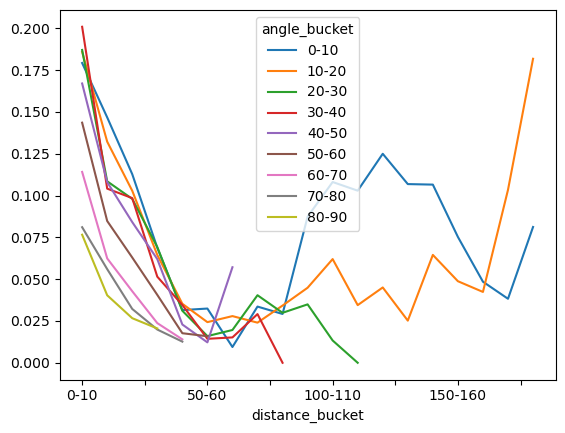

In [110]:
goal_rate_table.plot()

Text(0, 0.5, 'Goal Conversion Rate')

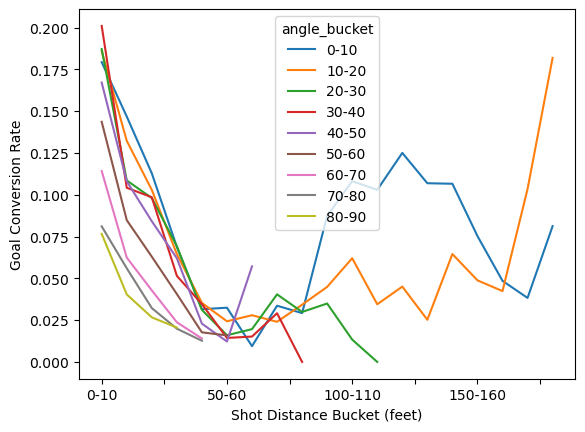

In [111]:
ax = goal_rate_table.plot()
ax.set_xlabel("Shot Distance Bucket (feet)")
ax.set_ylabel("Goal Conversion Rate")

## Conclusion

As with the last project, I see a trend of ***exponential decay among all shot angle buckets as distance increases***. 

**This is true up until about 70-75 feet**, which differs from where I originally posited before that empty-net goals started to skew the data ***(90+ feet)***. 

**A key idea to note about the empty-net shot is that while there is no goalie in the net, play is stopped and there is an "icing call" if the team that takes the empty net shot misses from 100+ feet(the center line).** (refer to https://en.wikipedia.org/wiki/Icing_(ice_hockey)).

With this information in mind, I'd like to split the data into two parts in further projects, in order to truly gauge the difference in shot probability from 0-75 feet, and from 75-200 feet. In this, two main questions will be answered.

1. Where, and at what angle are the most efficient shots taken when the goalie is most likely in the net(below 75 feet)?
2. Where, and at what angle are the most efficient shots taken when the goalie is most likely not in the net(75+ feet)?